In [2]:
import kagglehub
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.


In [3]:
import kagglehub
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")


Using Colab cache for faster access to the 'superstore-dataset-final' dataset.


In [4]:
import pandas as pd
import os

# List the contents of the downloaded path to find the dataset file
file_list = os.listdir(path)
print(f"Files in the dataset directory: {file_list}")

Files in the dataset directory: ['Sample - Superstore.csv']


In [5]:
# Assuming the dataset is a CSV file and is the first CSV found
csv_files = [f for f in file_list if f.endswith('.csv')]
if csv_files:
    dataset_file = os.path.join(path, csv_files[0])
    df = pd.read_csv(dataset_file, encoding='latin1')
    print(f"Loaded dataset from: {dataset_file}")
    display(df.head())
else:
    print("No CSV files found in the dataset directory.")

Loaded dataset from: /kaggle/input/superstore-dataset-final/Sample - Superstore.csv


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.dropna(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [13]:
df["Sales"].sum()

np.float64(2297200.8603000003)

In [14]:
df["Profit"].sum()

np.float64(286397.0217)

In [15]:
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


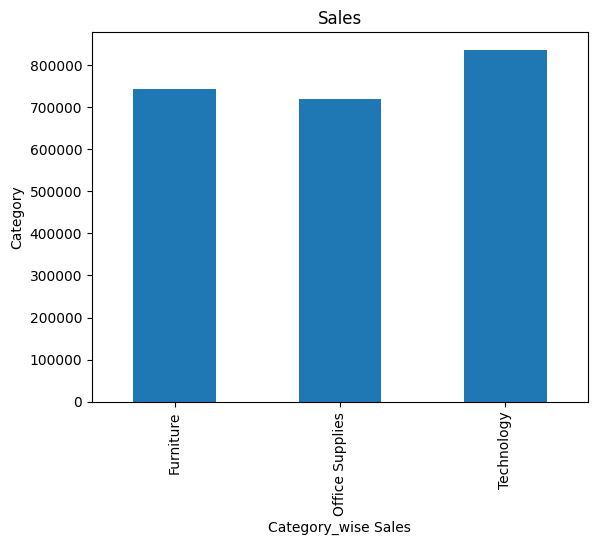

In [16]:
import matplotlib.pyplot as plt
category_sales.plot(kind="bar")
plt.xlabel("Category_wise Sales")
plt.ylabel("Category")
plt.title("Sales")
plt.show()

In [17]:
category_profit = df.groupby("Category")["Profit"].sum()
print(category_profit)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


In [18]:
region_sales = df.groupby("Region")["Sales"].sum()
print(region_sales)


Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


In [19]:
region_profit = df.groupby("Region")["Profit"].sum()
print(region_profit)

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


In [20]:
top_products=df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [21]:
top_profit_products=df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)
print(top_profit_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


In [22]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Month"]=df["Order Date"].dt.month_name()


In [23]:
monthly_sales=  df.groupby("Month")["Sales"].sum()
print(monthly_sales)

Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64


In [24]:
monthly_profit=df.groupby("Month")["Profit"].sum()
print(monthly_profit)

Month
April        11587.4363
August       21776.9384
December     43369.1919
February     10294.6107
January       9134.4461
July         13832.6648
June         21285.7954
March        28594.6872
May          22411.3078
November     35468.4265
October      31784.0413
September    36857.4753
Name: Profit, dtype: float64


In [25]:
import sqlite3
conn = sqlite3.connect("sales.db")
df.to_sql("sales",conn, if_exists="replace",index=False)

9994

In [26]:

query = """
SELECT * FROM SALES
LIMIT 5;
"""
result = pd.read_sql(query,conn)
print(result)

   Row ID        Order ID           Order Date   Ship Date       Ship Mode  \
0       1  CA-2016-152156  2016-11-08 00:00:00  11/11/2016    Second Class   
1       2  CA-2016-152156  2016-11-08 00:00:00  11/11/2016    Second Class   
2       3  CA-2016-138688  2016-06-12 00:00:00   6/16/2016    Second Class   
3       4  US-2015-108966  2015-10-11 00:00:00  10/18/2015  Standard Class   
4       5  US-2015-108966  2015-10-11 00:00:00  10/18/2015  Standard Class   

  Customer ID    Customer Name    Segment        Country             City  \
0    CG-12520      Claire Gute   Consumer  United States        Henderson   
1    CG-12520      Claire Gute   Consumer  United States        Henderson   
2    DV-13045  Darrin Van Huff  Corporate  United States      Los Angeles   
3    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   
4    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   

   ... Region       Product ID         Category Sub-Category  \
0  .

In [27]:
query ="""
SELECT COUNT(*)AS Total_Orders
FROM SALES;
"""
result = pd.read_sql(query,conn)
print(result)

   Total_Orders
0          9994


In [28]:
query ="""
SELECT SUM(Sales) AS Total_Sales
FROM SALES;
"""
result = pd.read_sql(query,conn)
print(result)

    Total_Sales
0  2.297201e+06


In [29]:
query ="""
SELECT AVG(Sales) AS Average_Sales
FROM SALES;
"""
result = pd.read_sql(query,conn)
print(result)

   Average_Sales
0     229.858001


In [30]:
query="""
SELECT Category,SUM(sales)AS Total_Sales
FROM SALES
GROUP BY Category;
"""
result = pd.read_sql(query,conn)
print(result)

          Category  Total_Sales
0        Furniture  741999.7953
1  Office Supplies  719047.0320
2       Technology  836154.0330


In [31]:
query ="""
SELECT Category,SUM(Profit)AS Total_Profit
FROM SALES
GROUP BY Category;
"""
result = pd.read_sql(query,conn)
print(result)

          Category  Total_Profit
0        Furniture    18451.2728
1  Office Supplies   122490.8008
2       Technology   145454.9481


In [32]:
query="""
SELECT [Product Name],SUM(Sales)AS Total_Sales
FROM SALES
GROUP BY [Product Name]
ORDER BY Total_Sales DESC
LIMIT 10;
"""
result = pd.read_sql(query,conn)
print(result)

                                        Product Name  Total_Sales
0              Canon imageCLASS 2200 Advanced Copier    61599.824
1  Fellowes PB500 Electric Punch Plastic Comb Bin...    27453.384
2  Cisco TelePresence System EX90 Videoconferenci...    22638.480
3       HON 5400 Series Task Chairs for Big and Tall    21870.576
4         GBC DocuBind TL300 Electric Binding System    19823.479
5   GBC Ibimaster 500 Manual ProClick Binding System    19024.500
6               Hewlett Packard LaserJet 3310 Copier    18839.686
7  HP Designjet T520 Inkjet Large Format Printer ...    18374.895
8          GBC DocuBind P400 Electric Binding System    17965.068
9        High Speed Automatic Electric Letter Opener    17030.312


In [33]:
query="""
SELECT[product Name],Sales,Profit
FROM sales
WHERE Category ='Technology'
LIMIT 10;
"""
result=pd.read_sql(query,conn )
print(result)


                                        Product Name     Sales    Profit
0                     Mitel 5320 IP Phone VoIP phone   907.152   90.7152
1      Konftel 250 Conference phone - Charcoal black   911.424   68.3568
2                            Cisco SPA 501G IP Phone   213.480   16.0110
3   Imation 8GB Mini TravelDrive USB 2.0 Flash Drive    90.570   11.7741
4                                        GE 30524EE4  1097.544  123.4737
5                    Plantronics HL10 Handset Lifter   371.168   41.7564
6                                 Panasonic Kx-TS550   147.168   16.5564
7  Verbatim 25 GB 6x Blu-ray Single Layer Recorda...    45.980   19.7714
8  Imation 8gb Micro Traveldrive Usb 2.0 Flash Drive    45.000    4.9500
9  LF Elite 3D Dazzle Designer Hard Case Cover, L...    21.800    6.1040


In [34]:
query="""
SELECT  [Product Name],Sales,Profit
FROM sales
WHERE Profit < 0
ORDER BY PROFIT ASC
LIMIT 10;
"""
result=pd.read_sql(query,conn )
print(result)

                                        Product Name      Sales     Profit
0          Cubify CubeX 3D Printer Double Head Print   4499.985 -6599.9780
1          Cubify CubeX 3D Printer Triple Head Print   7999.980 -3839.9904
2          GBC DocuBind P400 Electric Binding System   2177.584 -3701.8928
3          Lexmark MX611dhe Monochrome Laser Printer   2549.985 -3399.9800
4               Ibico EPK-21 Electric Binding System   1889.990 -2929.4845
5          Cubify CubeX 3D Printer Double Head Print   1799.994 -2639.9912
6  Fellowes PB500 Electric Punch Plastic Comb Bin...   1525.188 -2287.7820
7  Chromcraft Bull-Nose Wood Oval Conference Tabl...   4297.644 -1862.3124
8          GBC DocuBind P400 Electric Binding System   1088.792 -1850.9464
9  Cisco TelePresence System EX90 Videoconferenci...  22638.480 -1811.0784


In [35]:
query ="""
SELECT [Order ID],[Product Name],Sales,profit
FROM Sales
WHERE Profit < 0
ORDER BY Profit ASC
LIMIT 10;
"""
result = pd.read_sql(query,conn)
print(result)

         Order ID                                       Product Name  \
0  CA-2016-108196          Cubify CubeX 3D Printer Double Head Print   
1  US-2017-168116          Cubify CubeX 3D Printer Triple Head Print   
2  CA-2014-169019          GBC DocuBind P400 Electric Binding System   
3  CA-2017-134845          Lexmark MX611dhe Monochrome Laser Printer   
4  US-2017-122714               Ibico EPK-21 Electric Binding System   
5  CA-2015-147830          Cubify CubeX 3D Printer Double Head Print   
6  CA-2017-131254  Fellowes PB500 Electric Punch Plastic Comb Bin...   
7  CA-2015-116638  Chromcraft Bull-Nose Wood Oval Conference Tabl...   
8  CA-2016-130946          GBC DocuBind P400 Electric Binding System   
9  CA-2014-145317  Cisco TelePresence System EX90 Videoconferenci...   

       Sales     Profit  
0   4499.985 -6599.9780  
1   7999.980 -3839.9904  
2   2177.584 -3701.8928  
3   2549.985 -3399.9800  
4   1889.990 -2929.4845  
5   1799.994 -2639.9912  
6   1525.188 -2287.7820  

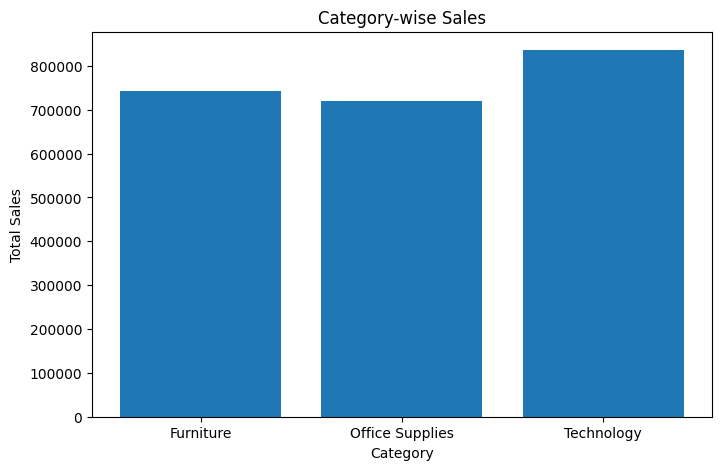

In [36]:
import matplotlib.pyplot as plt
category_sales=df.groupby("Category")["Sales"].sum()
plt.figure(figsize=(8,5))
plt.bar(category_sales.index,category_sales.values)
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

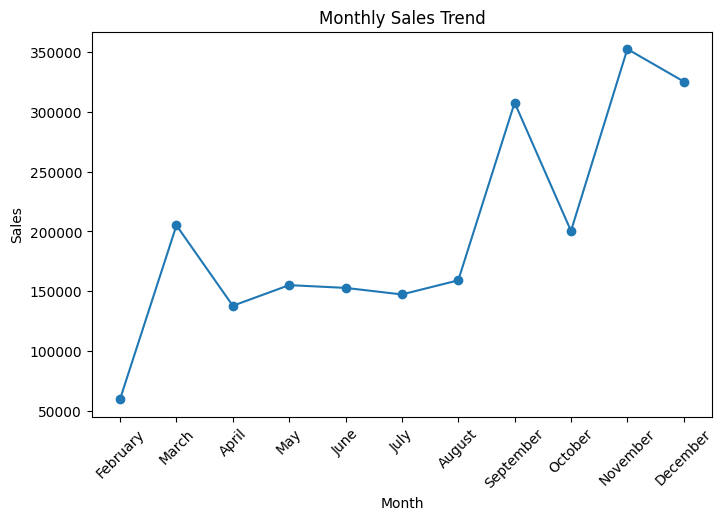

In [37]:
monthly_sales=df.groupby("Month")["Sales"].sum()
month_order=["january","February","March","April","May","June","July","August","September","October","November","December"]
monthly_sales=monthly_sales.reindex(month_order)
plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index,monthly_sales.values,marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show

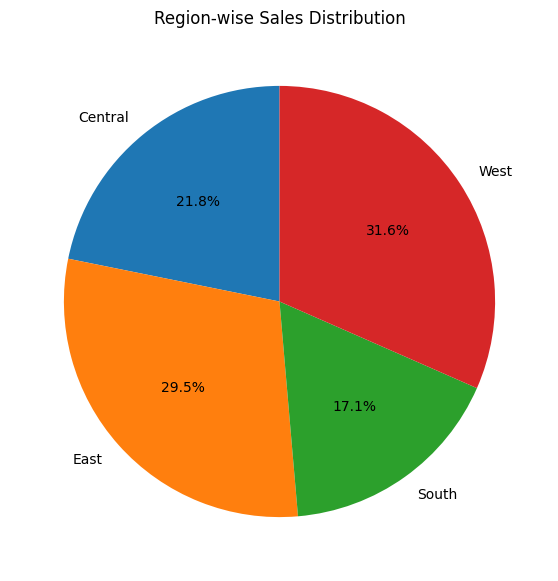

In [38]:
region_sales= df.groupby("Region")["Sales"].sum()
plt.figure(figsize=(7,7))
plt.pie(region_sales.values,labels=region_sales.index,autopct="%1.1f%%",
        startangle=90)
plt.title("Region-wise Sales Distribution")
plt.show()

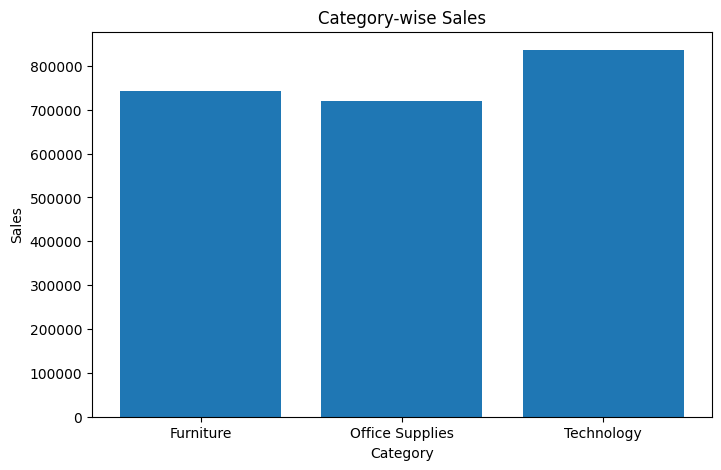

In [40]:
import matplotlib.pyplot as plt
category_sales=df.groupby("Category")["Sales"].sum()
plt.figure(figsize=(8,5))
plt.bar(category_sales.index,category_sales.values)
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.savefig("category_sales.png",dpi=300,bbox_inches="tight")
plt.show()

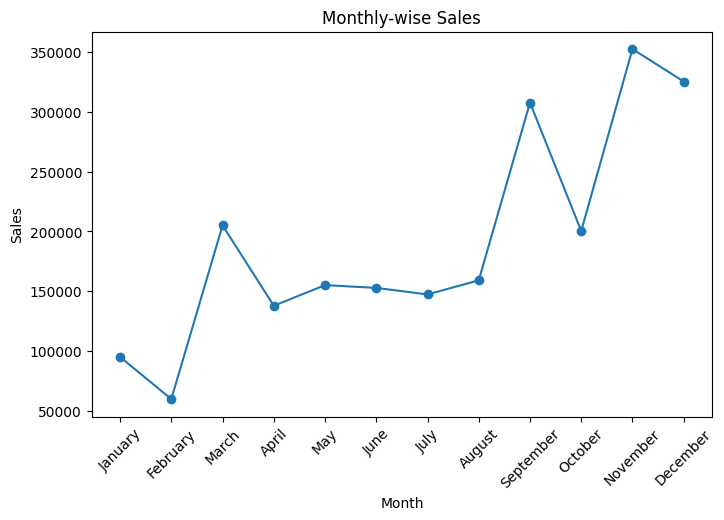

In [45]:
import matplotlib.pyplot as plt

# Corrected column name from "monthly" to "Month"
monthly_sales = df.groupby("Month")["Sales"].sum()

# Reindex for consistent month order, using capitalized month names
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values,marker="o")
plt.title("Monthly-wise Sales") # Corrected capitalization for consistency
plt.xlabel("Month") # Corrected capitalization for consistency
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.savefig("monthly_sales.png",dpi=300,bbox_inches="tight")
plt.show()

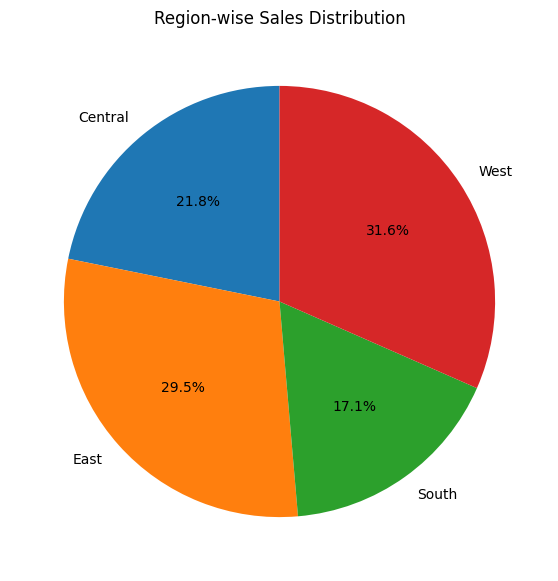

In [46]:
region_sales= df.groupby("Region")["Sales"].sum()
plt.figure(figsize=(7,7))
plt.pie(region_sales.values,labels=region_sales.index,autopct="%1.1f%%",
        startangle=90)
plt.title("Region-wise Sales Distribution")
plt.savefig("region_sales.png",dpi=300,bbox_inches="tight")
plt.show()

In [47]:
df.to_csv("cleaned_sales_data.csv",index=False)
print("cleaned dataset saved successfully!")

cleaned dataset saved successfully!


In [49]:
requirments="""pandas
matplotlib
numpy
sqlite3
"""
with open("requirements.txt","w") as file:
    file.write(requirments)
print("requirements saved successfully!")

requirements saved successfully!


In [52]:
readme = """# Sales Performance Analysis using Python & SQL

## Project Overview
This project analyzes retail sales data using Python, Pandas, SQL, and Matplotlib to identify business insights and visualize sales performance.

## Tools Used
- Python
- Pandas
- NumPy
- SQLite
- Matplotlib
- Google Colab

## Dataset
Sample Superstore Dataset

## Project Workflow
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. SQL Analysis
5. Data Visualization
6. Business Insights

## SQL Concepts Used
- SELECT
- WHERE
- GROUP BY
- ORDER BY
- LIMIT
- COUNT()
- SUM()
- AVG()

## Visualizations
- Category-wise Sales (Bar Chart)
- Monthly Sales Trend (Line Chart)
- Region-wise Sales Distribution (Pie Chart)

## Key Business Insights
- Technology category generated the highest sales and profit.
- West region achieved the highest sales.
- November recorded the highest monthly sales.
- Canon imageCLASS 2200 Advanced Copier was the highest-selling product.

## Author
Archana CR
"""

with open("README.md", "w") as file:
    file.write(readme)

print("README.md created successfully!")

README.md created successfully!
